In [1]:
# Repository bootstrap: make local packages importable from any notebook working directory.
from pathlib import Path
import sys
_HERE = Path.cwd().resolve()
_REPO_ROOT = next((p for p in (_HERE, *_HERE.parents) if (p / 'publication_reconstruction').is_dir() and (p / 'data').is_dir()), None)
if _REPO_ROOT is None:
    raise RuntimeError('Could not locate repository root from the notebook working directory.')
if str(_REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(_REPO_ROOT))


# Doppler Broadening — Synthetic Spectroscopy

**Synthetic demonstration:** wavelength calibration → line identification → Gaussian fitting → Doppler broadening → ion temperature.

This notebook uses controlled synthetic data; it is not a reconstruction of an original IR-T1 spectrum.

In [2]:
import sys
from pathlib import Path
ROOT = Path.cwd().resolve()
if (ROOT / 'spectroscopy').exists():
    repo_root = ROOT
else:
    repo_root = ROOT.parent.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import numpy as np
import matplotlib.pyplot as plt
from spectroscopy.synthetic import generate_synthetic_spectrum
from spectroscopy.calibration.wavelength import calibrate_wavelength
from spectroscopy.line_identification.identification import SpectralLineReference, identify_spectral_lines
from spectroscopy.spectral_fitting.gaussian import fit_gaussian_peak
from spectroscopy.doppler_broadening.temperature import estimate_doppler_temperature
from spectroscopy.visualization import plot_calibration_residual, plot_line_identification, plot_gaussian_fit, plot_temperature_validation

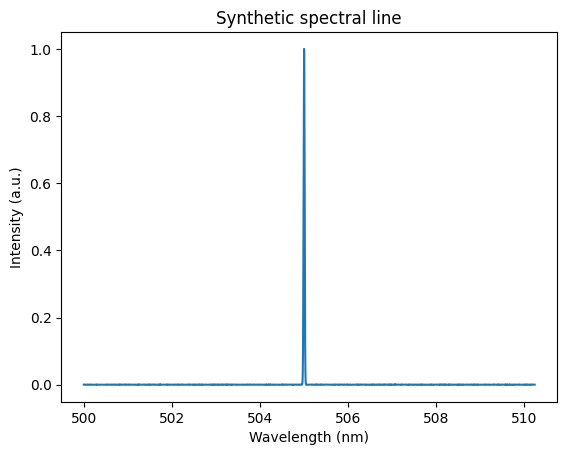

In [3]:
s = generate_synthetic_spectrum(noise_std=0.0002, baseline_coefficients=(0.0, 0.0))
plt.figure()
plt.plot(s.wavelength * 1e9, s.intensity)
plt.xlabel('Wavelength (nm)')
plt.ylabel('Intensity (a.u.)')
plt.title('Synthetic spectral line')
plt.show()

Calibration RMS residual: 1.49736e-10 pm


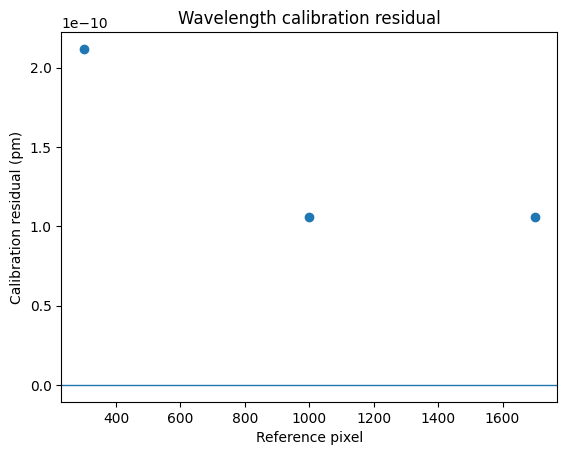

In [4]:
ref_pixels = np.array([300, 1000, 1700])
ref_wavelengths = s.true_wavelength[ref_pixels]
cal = calibrate_wavelength(ref_pixels, ref_wavelengths, degree=1)
calibrated_wavelength = cal.calibrate(s.pixels)
print(f'Calibration RMS residual: {cal.rms_residual * 1e12:.6g} pm')
fig, ax = plt.subplots()
plot_calibration_residual(cal, ax=ax)
plt.show()

Number of candidate matches: 1
{'reference': SpectralLineReference(species='Ar', ionization_stage='I', rest_wavelength=5.05e-07, optional_relative_intensity=None, source='synthetic/reference'), 'detected_wavelength': 5.049999999999998e-07, 'peak_index': 1000, 'difference': -2.117582368135751e-22, 'intensity': 0.9999881434707948}


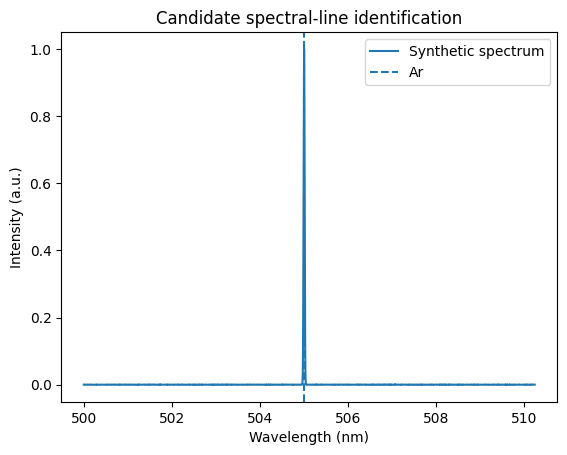

In [5]:
reference = SpectralLineReference('Ar', 'I', s.line_center, source='synthetic/reference')
matches = identify_spectral_lines(calibrated_wavelength, s.intensity, [reference], tolerance=0.5e-9, prominence=0.1)
print(f'Number of candidate matches: {len(matches)}')
if matches:
    print(matches[0])
fig, ax = plt.subplots()
plot_line_identification(calibrated_wavelength, s.intensity, matches, ax=ax)
plt.show()

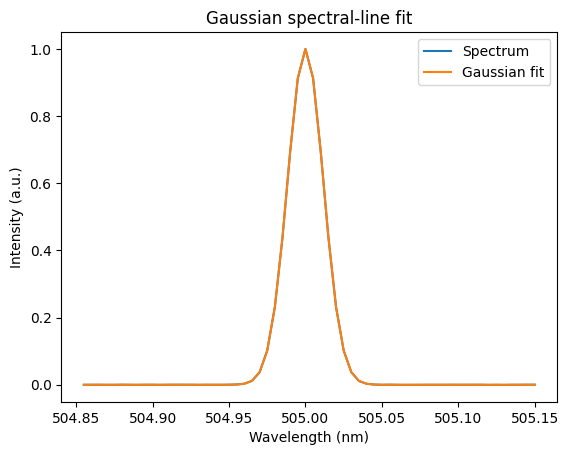

Fitted center: 504.999999 nm
Fitted sigma: 11.701562 pm
Fitted FWHM: 27.555072 pm


In [6]:
mask = np.abs(calibrated_wavelength - s.line_center) <= 0.15e-9
fit = fit_gaussian_peak(calibrated_wavelength[mask], s.intensity[mask], initial_guess=(1.0, s.line_center, s.doppler_sigma))
fig, ax = plt.subplots()
plot_gaussian_fit(calibrated_wavelength[mask], s.intensity[mask], fit, ax=ax)
plt.show()
print(f'Fitted center: {fit.center * 1e9:.6f} nm')
print(f'Fitted sigma: {fit.sigma * 1e12:.6f} pm')
print(f'Fitted FWHM: {fit.fwhm * 1e12:.6f} pm')

Known Ti:      20.0000 eV
Recovered Ti:  20.0053 eV
Recovered Ti:  2.3215e+05 K


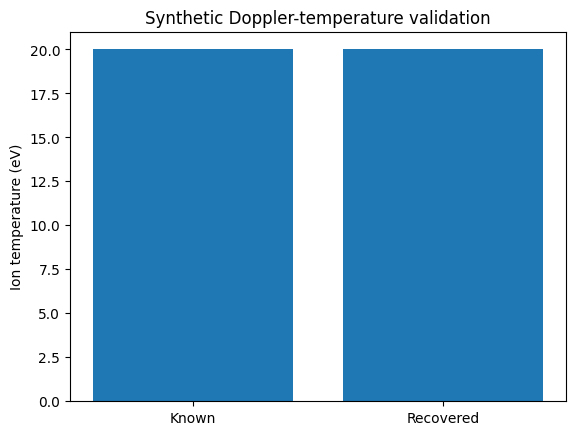

In [7]:
temperature = estimate_doppler_temperature(s.line_center, fit.sigma, s.atomic_mass_amu, instrumental_sigma=s.instrumental_sigma)
print(f'Known Ti:      {s.temperature_eV:.4f} eV')
print(f'Recovered Ti:  {temperature["temperature_eV"]:.4f} eV')
print(f'Recovered Ti:  {temperature["temperature_K"]:.4e} K')
fig, ax = plt.subplots()
plot_temperature_validation(s.temperature_eV, temperature['temperature_eV'], ax=ax)
plt.show()